# Predicting Stock Returns with Geometric Brownian Motion
 

In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
import datetime as dt
import portfolio_value as pv
import matplotlib.pyplot as plt

## Importing Stock Data


In [ ]:
start_date = dt.datetime(2025,1,1)
end_date = dt.datetime(2026,5,1)

stock_data = yf.download(['AAPL'], start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


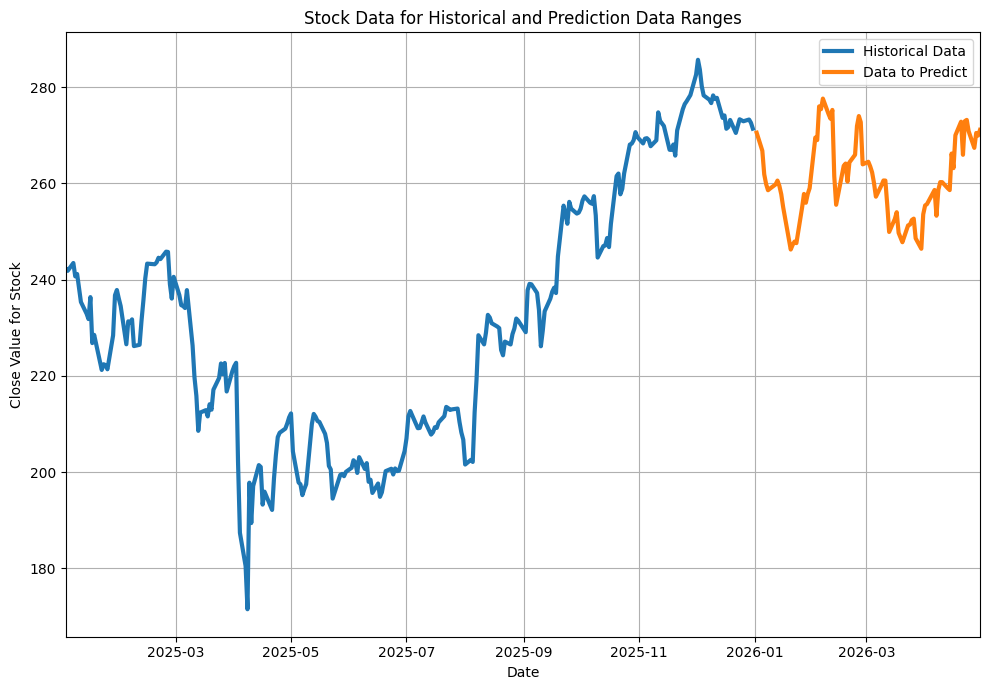

In [44]:
plt.figure(figsize=(10,7))
plt.plot(stock_data['Close']['2025-01-02':'2025-12-31'], linewidth=3, label='Historical Data')
plt.plot(stock_data['Close']['2026-01-01':'2026-5-1'], linewidth=3, label='Data to Predict')
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Stock'); plt.legend()
plt.xlim(left=min(stock_data['Close'].index), right=max(stock_data['Close'].index))
plt.title('Stock Data for Historical and Prediction Data Ranges')
plt.tight_layout()

### Computing Returns from Data

In [37]:
initial_value = 1000
data_returns = stock_data['Close']['2026-01-01':'2026-5-1'].pct_change().to_numpy()[:,0]
data_log_returns = np.log(1+data_returns)

In [38]:
asset_value = np.zeros(data_returns.shape, dtype=float) 
asset_value[0] = initial_value
for ii in range(1,asset_value.shape[0]):
    asset_value[ii] = asset_value[ii-1]*np.exp(data_log_returns[ii])

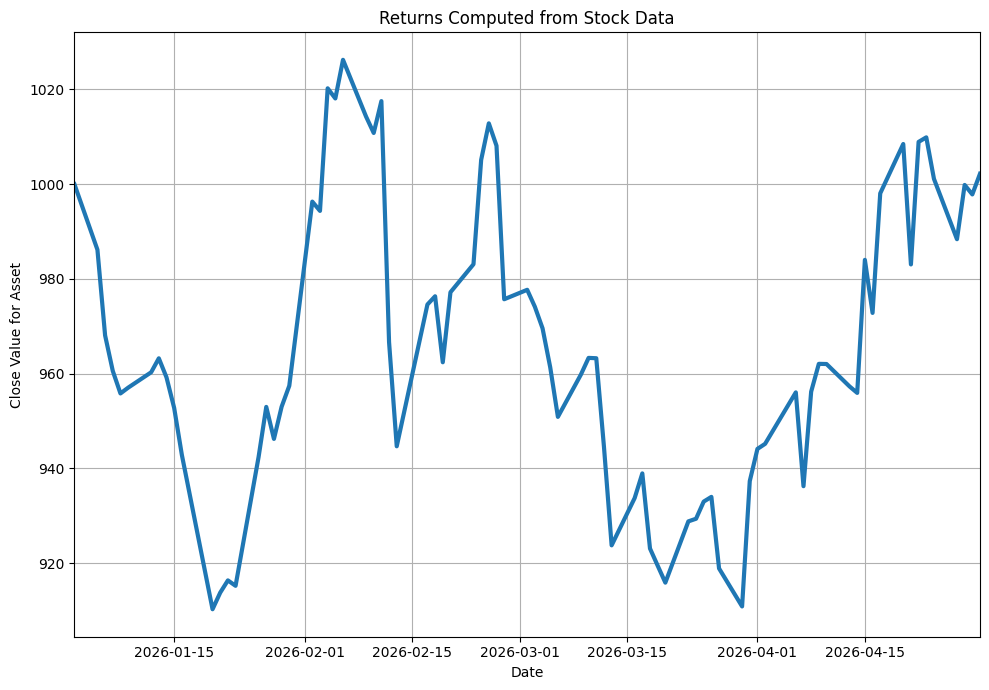

In [45]:
plt.figure(figsize=(10,7))
plt.plot(stock_data['2026-01-01':'2026-5-1'].index, asset_value, linewidth=3)
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Asset');
plt.xlim(left=min(stock_data['2026-01-01':'2026-5-1'].index),
         right=max(stock_data['2026-01-01':'2026-5-1'].index))
plt.title('Returns Computed from Stock Data')
plt.tight_layout()

## Building the Fund Value Object

In [51]:
stock_value_object = pv.FundValue(stock_data['Close']['2025-01-02':'2025-12-31']['AAPL'], 
                                  initial_value=initial_value)
stock_value_object.predict_value_monte_carlo(start_date=dt.datetime(2026,1,1),
                                             end_date=dt.datetime(2026,5,1),
                                             number_of_realizations=1000)

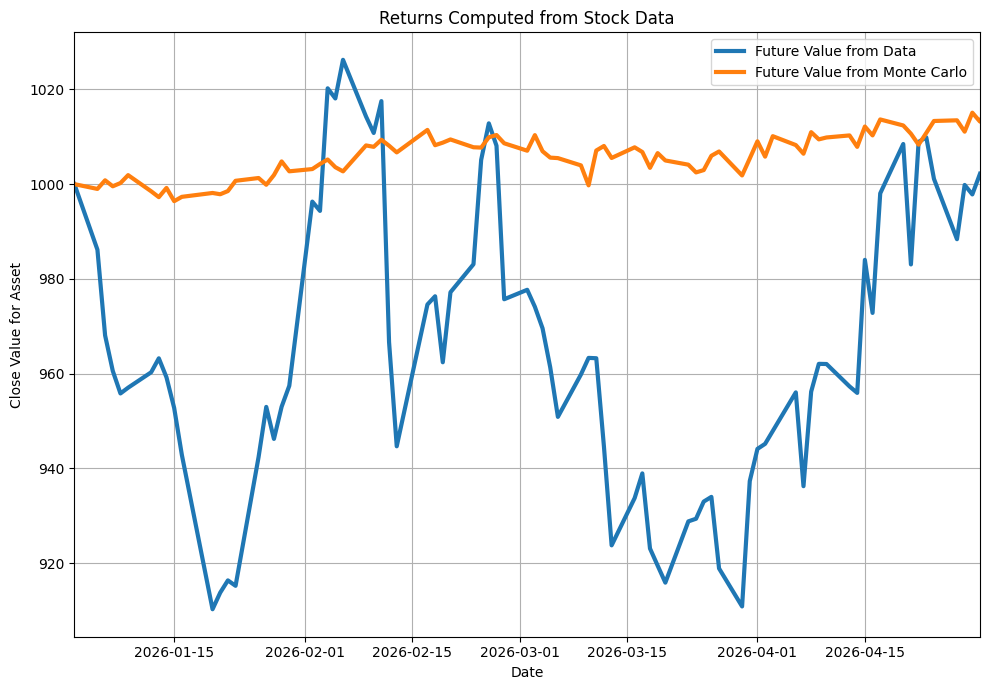

In [56]:
plt.figure(figsize=(10,7))
plt.plot(stock_data['2026-01-01':'2026-5-1'].index, asset_value, linewidth=3, 
         label='Future Value from Data')
plt.plot(stock_value_object.predicted_value_date_range, 
         stock_value_object.future_fund_value_quantile(0.5), 
         linewidth=3, label='Future Value from Monte Carlo')
plt.grid(); plt.xlabel('Date'); plt.ylabel('Close Value for Asset');
plt.xlim(left=min(stock_data['2026-01-01':'2026-5-1'].index),
         right=max(stock_data['2026-01-01':'2026-5-1'].index))
plt.title('Returns Computed from Stock Data'); plt.legend()
plt.tight_layout()

